In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/16_air_quality_prediction.csv")
df

,date,location,pm2.5,pm10,temperature,predicted_aqi
0,2023-01-01,Istanbul,29.05,58.73,15.4,40.71
1,2023-01-01,Ankara,24.74,83.86,26.4,50.63
2,2023-01-01,Izmir,23.90,76.91,27.8,39.67
3,2023-01-01,Bursa,43.67,49.58,30.6,36.50
4,2023-01-02,Istanbul,28.40,76.31,23.9,46.89
...,...,...,...,...,...,...
1455,2023-12-30,Bursa,32.45,92.85,19.0,54.18
1456,2023-12-31,Istanbul,35.23,63.02,23.2,46.39
1457,2023-12-31,Ankara,45.30,47.77,8.4,44.05
1458,2023-12-31,Izmir,37.29,64.74,30.9,52.19


In [ ]:
df.isnull().sum()

,0
date,0
location,0
pm2.5,0
pm10,0
temperature,0
predicted_aqi,0


In [ ]:
df = df.dropna()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

In [ ]:
df = df.drop('date', axis=1)

In [ ]:
print("Locations in dataset:")
print(df['location'].unique())

Locations in dataset:
['Istanbul' 'Ankara' 'Izmir' 'Bursa']


In [ ]:
df

,location,pm2.5,pm10,temperature,predicted_aqi,year,month,day
0,Istanbul,29.05,58.73,15.4,40.71,2023,1,1
1,Ankara,24.74,83.86,26.4,50.63,2023,1,1
2,Izmir,23.90,76.91,27.8,39.67,2023,1,1
3,Bursa,43.67,49.58,30.6,36.50,2023,1,1
4,Istanbul,28.40,76.31,23.9,46.89,2023,1,2
...,...,...,...,...,...,...,...,...
1455,Bursa,32.45,92.85,19.0,54.18,2023,12,30
1456,Istanbul,35.23,63.02,23.2,46.39,2023,12,31
1457,Ankara,45.30,47.77,8.4,44.05,2023,12,31
1458,Izmir,37.29,64.74,30.9,52.19,2023,12,31


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1460, 8)


In [ ]:
X = df.drop('predicted_aqi', axis=1)
y = df['predicted_aqi']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Support Vector Machine": SVR()
}

In [ ]:
results = []

categorical_cols = ['location']
numerical_cols = ['pm2.5', 'pm10', 'temperature', 'year', 'month', 'day']

for name, model in models.items():

    if name in ["Linear Regression", "Support Vector Machine"]:
        preprocessor = ColumnTransformer(
            transformers=[
                ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
                ('num', StandardScaler(), numerical_cols)
            ]
        )
    else:
        preprocessor = ColumnTransformer(
            transformers=[
                ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
                ('num', 'passthrough', numerical_cols)
            ]
        )

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')
    cv_mean = cv_scores.mean()

    results.append([name, mae, mse, r2, cv_mean, pipeline])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "R2 Score", "CV R2 Mean", "Pipeline"])
results_df.drop("Pipeline", axis=1)

,Model,MAE,MSE,R2 Score,CV R2 Mean
0,Linear Regression,4.035701,26.176902,0.706381,0.731426
1,Decision Tree,5.693630,53.424718,0.400749,0.388054
2,Random Forest,4.491145,33.449359,0.624807,0.682243
3,Support Vector Machine,4.721676,36.990697,0.585085,0.614914


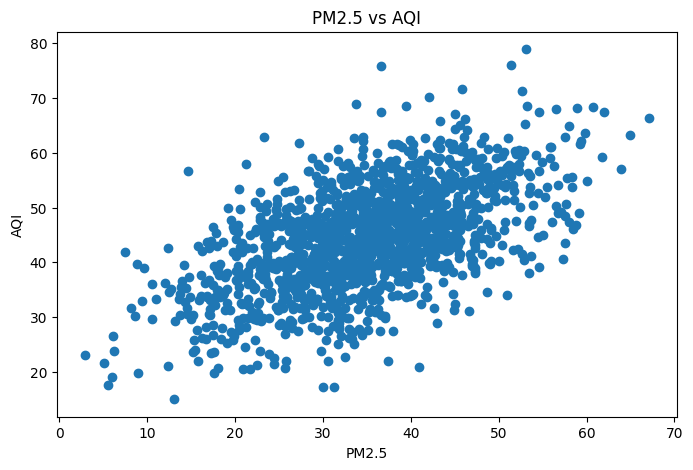

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['pm2.5'], df['predicted_aqi'])
plt.title("PM2.5 vs AQI")
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.show()

In [ ]:
best_index = results_df['R2 Score'].idxmax()
best_model_row = results_df.loc[best_index]

print("Best Model Details:")
print(best_model_row[['Model', 'MAE', 'MSE', 'R2 Score', 'CV R2 Mean']])

Best Model Details:
Model         Linear Regression
MAE                    4.035701
MSE                   26.176902
R2 Score               0.706381
CV R2 Mean             0.731426
Name: 0, dtype: object


In [ ]:
results_df[['Model', 'MAE', 'MSE', 'R2 Score', 'CV R2 Mean']].sort_values(by='R2 Score', ascending=False)

,Model,MAE,MSE,R2 Score,CV R2 Mean
0,Linear Regression,4.035701,26.176902,0.706381,0.731426
2,Random Forest,4.491145,33.449359,0.624807,0.682243
3,Support Vector Machine,4.721676,36.990697,0.585085,0.614914
1,Decision Tree,5.693630,53.424718,0.400749,0.388054


In [ ]:
best_model_name = best_model_row['Model']
best_pipeline = results_df.loc[best_index, 'Pipeline']

y_pred = best_pipeline.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

pickle.dump(best_pipeline, open('aqi_model.pkl', 'wb'))

First 10 Predictions:
[44.85842452 49.22776664 51.06710324 47.90261223 36.42577358 48.00495328
 43.67662487 51.49041792 35.00242068 34.89581329]


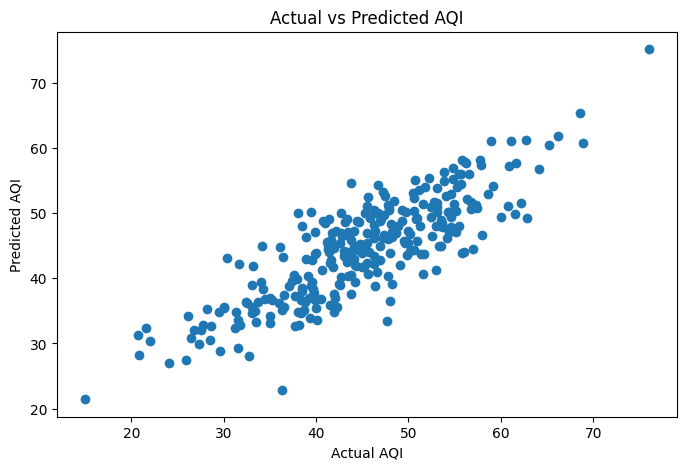

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)
plt.title("Actual vs Predicted AQI")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.show()

In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 86.3 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle

model = pickle.load(open("aqi_model.pkl", "rb"))

def get_aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

locations = ['Istanbul', 'Ankara', 'Izmir', 'Bursa']

st.title("Air Quality Index Prediction System")
st.write("Enter pollution and weather details to predict AQI and category.")

location = st.selectbox("Location", locations)
pm25 = st.number_input("PM2.5", min_value=0.0, value=25.0)
pm10 = st.number_input("PM10", min_value=0.0, value=40.0)
temperature = st.number_input("Temperature", value=22.0)
year = st.number_input("Year", min_value=2000, max_value=2100, value=2025, step=1)
month = st.number_input("Month", min_value=1, max_value=12, value=4, step=1)
day = st.number_input("Day", min_value=1, max_value=31, value=10, step=1)

if st.button("Predict AQI"):
    input_df = pd.DataFrame([{
        'location': location,
        'pm2.5': pm25,
        'pm10': pm10,
        'temperature': temperature,
        'year': int(year),
        'month': int(month),
        'day': int(day)
    }])

    prediction = model.predict(input_df)[0]
    category = get_aqi_category(prediction)

    st.subheader("Prediction Result")
    st.success(f"Predicted AQI: {round(prediction, 2)}")
    st.info(f"AQI Category: {category}")

Writing app.py


In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("3CApfAHFhGdcNnZvDvjpfMuC1bk_2MTQbFzhBW5DFuVcqUySG")

In [ ]:
import subprocess

process = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port", "8501"]
)

print("Streamlit started")

Streamlit started


In [ ]:
import time
time.sleep(10)
print("Waited 10 seconds")

Waited 10 seconds


In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print("App Link:", public_url)

App Link: NgrokTunnel: "https://hypermagically-clergylike-sophia.ngrok-free.dev" -> "http://localhost:8501"
